In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

# Caminho da pasta com os CSVs
pasta = "./tests/results"

# Listas para médias
rows = []

In [3]:
# Ler todos os CSV da pasta
for arquivo in os.listdir(pasta):
    if arquivo.endswith('.csv'):
        parts = arquivo.split('-')
        broadphase = '_'.join(parts[2:4])

        collision = parts[4]
        if collision == 'gjk':
            collision = '_'.join(parts[4:6])
            count = parts[6]
        else:
            count = parts[5]

        if count.isnumeric() == False:
            continue

        caminho = os.path.join(pasta, arquivo)

        df = pd.read_csv(caminho)
        rows.append([
            df["collisions_test"].mean(), 
            df["true_collisions"].mean(), 
            df["dt"].mean(), 
            int(count), 
            broadphase, 
            collision
        ])

In [4]:

df = pd.DataFrame(rows, columns=["collisions_test", "true_collisions", "dt", "count", "broadphase", "collision"])


In [5]:
styles = {
    ("naive_mode", "sat"): {"linestyle": "-", "marker": "o"},
    ("grid_mode", "sat"): {"linestyle": "-", "marker": "o"},
    ("naive_mode", "gjk_epa"): {"linestyle": "--", "marker": "s"},
    ("grid_mode", "gjk_epa"): {"linestyle": "--", "marker": "s"},
}

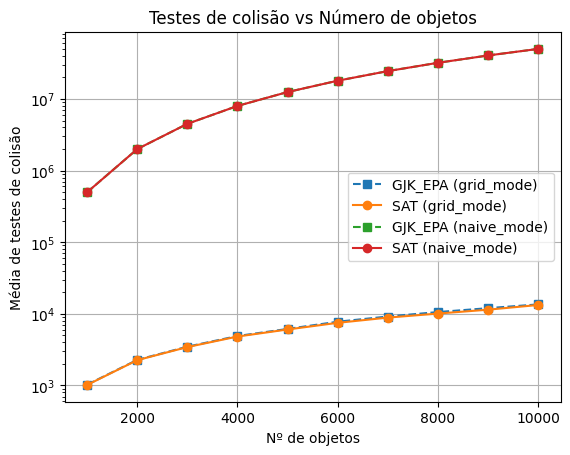

In [6]:
# Agrupar por broadphase e collision
groups = df.groupby(["broadphase", "collision"])

fig, ax = plt.subplots()

# Gerar um gráfico para cada grupo
for (broadphase, collision), g in groups:
    g = g.sort_values("count")

    label = f"{collision.upper()} ({broadphase})"
    
    style = styles[(broadphase, collision)]
    ax.plot(
        g["count"], 
        g["collisions_test"], 
        label=label, 
        linestyle=style["linestyle"],
        marker=style["marker"]
    )

ax.set_xlabel("Nº de objetos")
ax.set_ylabel("Média de testes de colisão")
ax.set_title("Testes de colisão vs Número de objetos")
ax.set_yscale("log")
ax.legend()
ax.grid()

plt.savefig("./tests/results/figures/comparativo-testes-colisao.png")
plt.show()

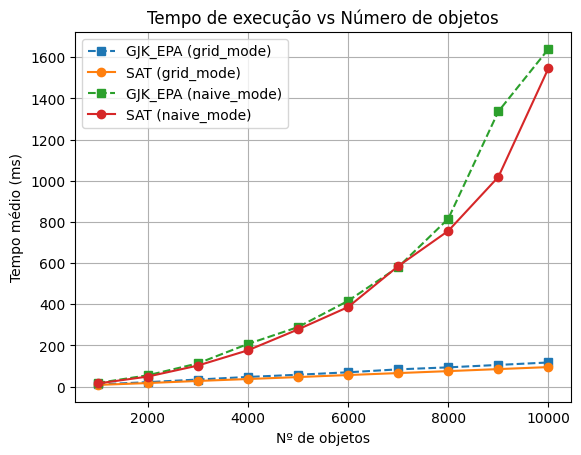

In [7]:
# Agrupar por broadphase e collision
groups = df.groupby(["broadphase", "collision"])

fig, ax = plt.subplots()

# Gerar um gráfico para cada grupo
for (broadphase, collision), g in groups:
    # if broadphase == 'naive_mode': continue

    g = g.sort_values("count")

    label = f"{collision.upper()} ({broadphase})"
    
    style = styles[(broadphase, collision)]
    ax.plot(
        g["count"], 
        g["dt"], 
        label=label, 
        linestyle=style["linestyle"],
        marker=style["marker"]
    )

ax.set_xlabel("Nº de objetos")
ax.set_ylabel("Tempo médio (ms)")
ax.set_title("Tempo de execução vs Número de objetos")
ax.legend()
ax.grid()

plt.savefig("./tests/results/figures/comparativo-tempo-execução.png")
plt.show()